In [130]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gdown.download(r'https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: c:\data\ns_book7.csv
100%|██████████| 53.8M/53.8M [00:04<00:00, 11.4MB/s]


C:\Users\박중현\AppData\Local\Temp\ipykernel_240\1466509664.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ns_book['주제분류번호'] = ns_book['주제분류번호'].astype('string').str[0].astype('Int64')
C:\Users\박중현\AppData\Local\Temp\ipykernel_240\1466509664.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


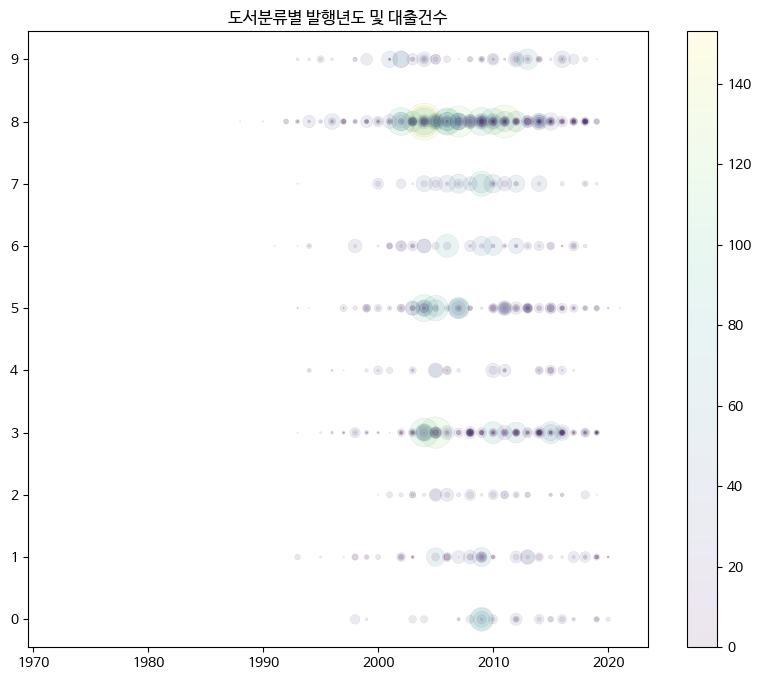

In [157]:
plt.rc('font', family='NanumBarunGothic')

ns_book = ns_book7[ns_book7['주제분류번호'].notna()]
ns_book['주제분류번호'] = ns_book['주제분류번호'].astype('string').str[0].astype('Int64')
ns_book1 = ns_book.sample(1000, random_state=40).copy()


fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(ns_book1['발행년도'], ns_book1['주제분류번호'], linewidths=0.3, edgecolors='black', s=ns_book1['대출건수']**1.3, c=ns_book1['대출건수'], alpha=0.1)
ax.set_title('도서분류별 발행년도 및 대출건수')
ax.set_yticks(range(10))
fig.colorbar(sc)
fig.show()

C:\Users\박중현\AppData\Local\Temp\ipykernel_240\3571484995.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


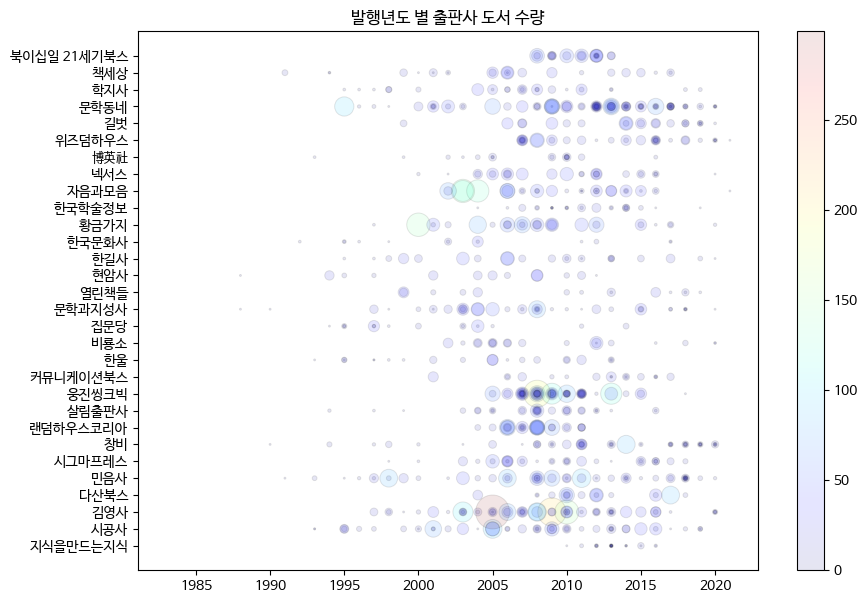

In [159]:
sample = ns_book7['출판사'].value_counts()[:30]
ns_book8 = ns_book7[ns_book7['출판사'].isin(sample.index)].sample(1000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(ns_book8['발행년도'], ns_book8['출판사'],
                alpha=0.1,
                s=ns_book8['대출건수']*2,
                c=ns_book8['대출건수'],
                edgecolors='black',
                linewidths=0.7,
                cmap='jet')
ax.set_title('발행년도 별 출판사 도서 수량')
fig.colorbar(sc)
fig.show()
